In [216]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', None)

In [217]:
df = pd.read_csv("StudentPerformanceFactors.csv")

# Seeing data at a glance

In [218]:
df.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [219]:
df.shape

(6607, 20)

In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [221]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


df.isnull().sum()

In [222]:
df.drop_duplicates()
df.shape

### As the row number before and after of the dataframe is same, there is no duplicates

(6607, 20)

Our target variable is test score , so , we have to find relation with 

In [223]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [224]:
num_cols = ['Hours_Studied', 'Attendance',
        'Sleep_Hours',
       'Previous_Scores', 
       'Tutoring_Sessions', 'Physical_Activity','Exam_Score']

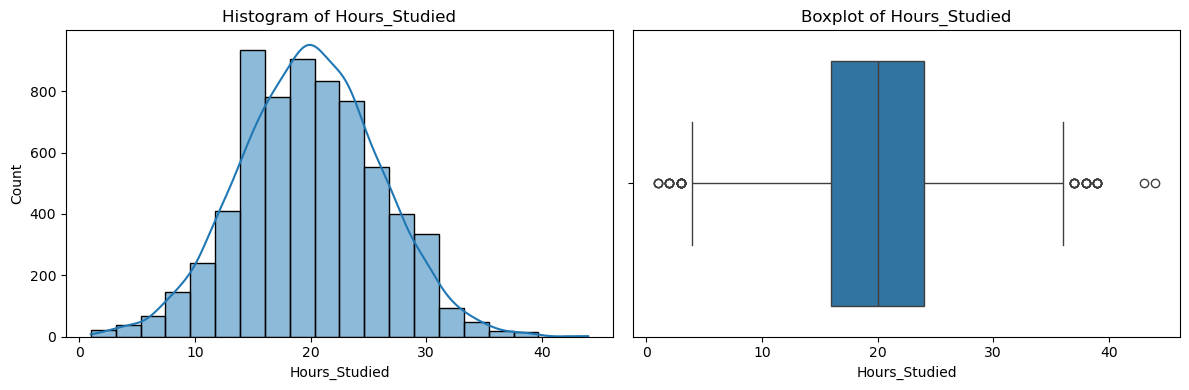

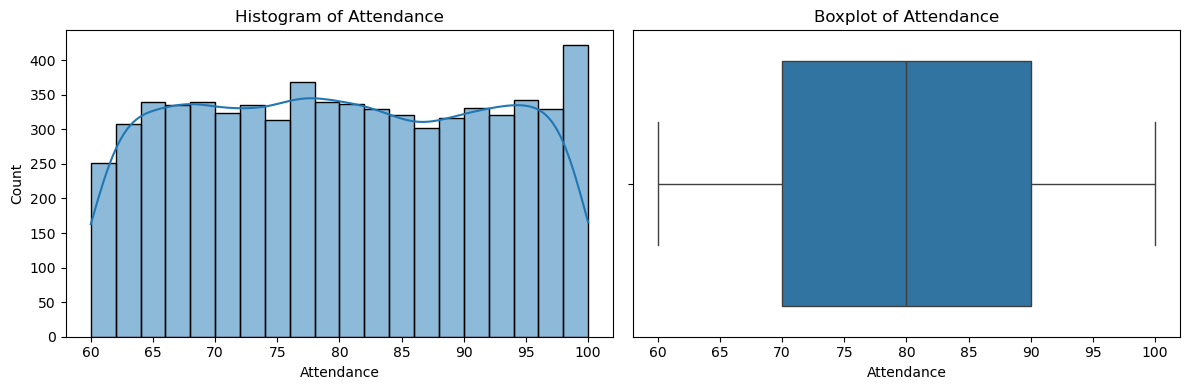

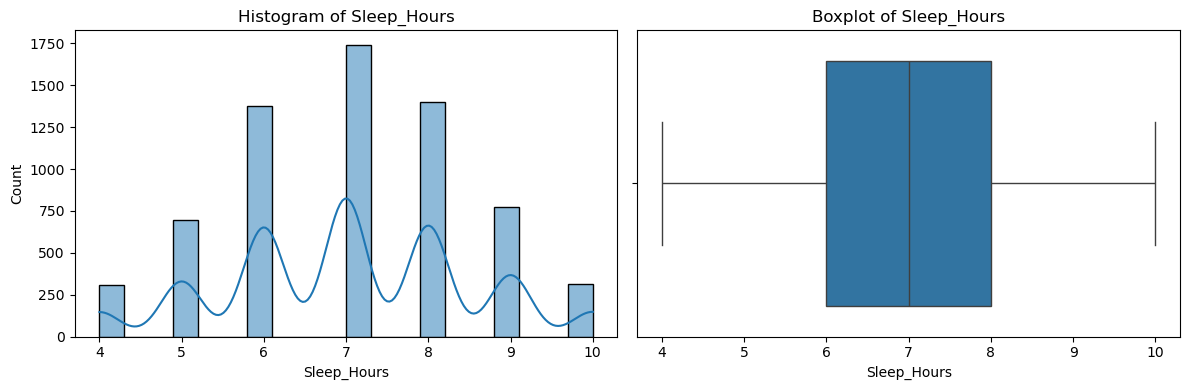

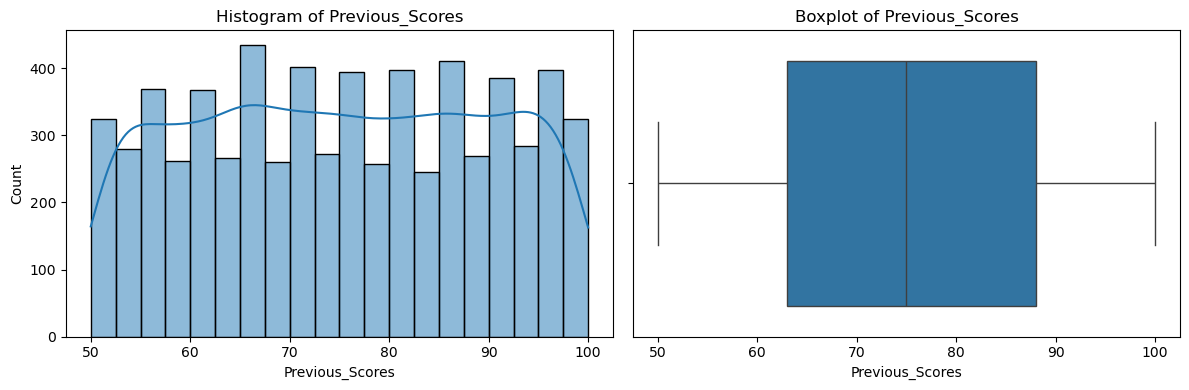

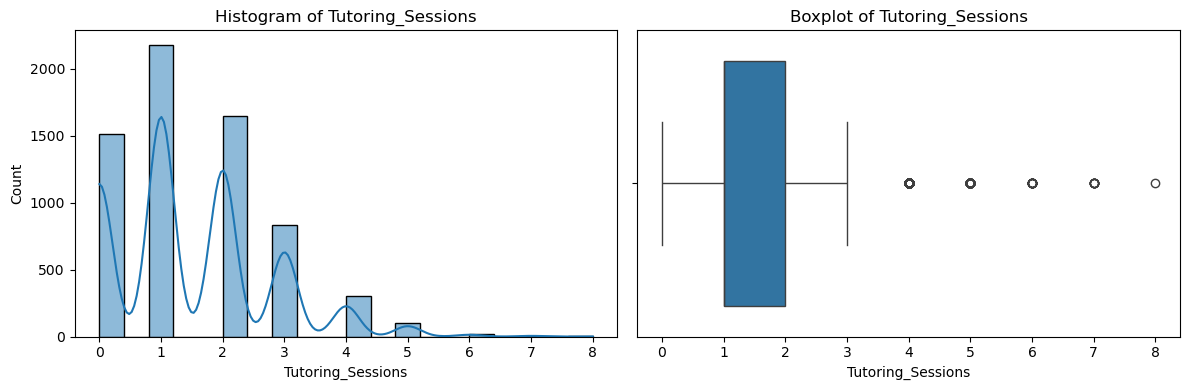

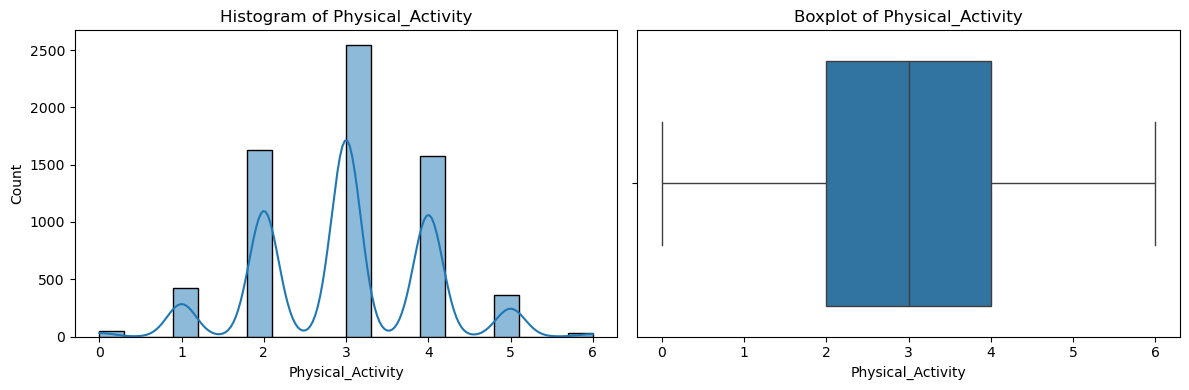

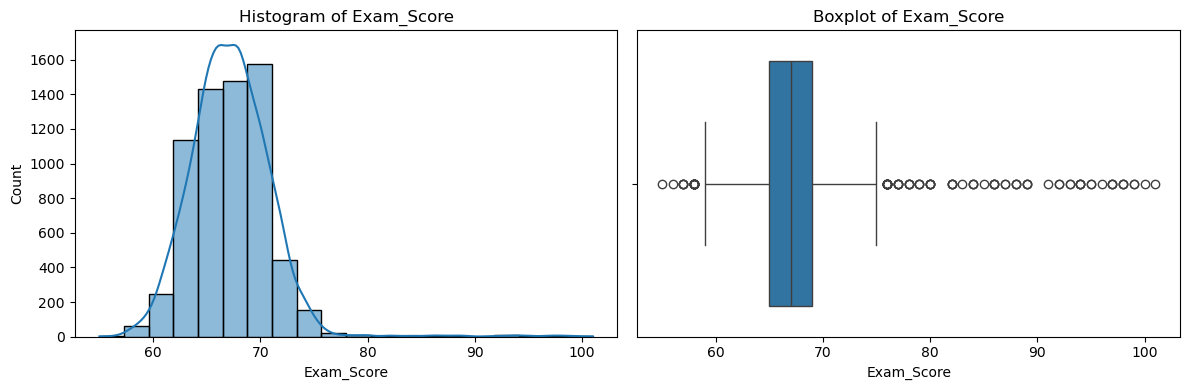

In [225]:
# for col in num_cols:
#     plt.figure(figsize=(6,4))
#     sns.histplot(df[col],kde=True,bins=20)
#     plt.figure(figsize=(6,4))
#     sns.boxplot(x=df[col])


import matplotlib.pyplot as plt
import seaborn as sns

# Assuming num_cols and df are already defined
for col in num_cols:
    # Create a figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 1. Plot Histogram on the first axis (index 0)
    sns.histplot(df[col], kde=True, bins=20, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    
    # 2. Plot Boxplot on the second axis (index 1)
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    # Adjust layout so labels don't overlap
    plt.tight_layout()
    plt.show()

# The first graph shows , most of the students studies for 15-25 hours weekly (Gaussian Distribution).
# The 2nd graph shows , most of the students have attendence of 70-90 percent (Normal Distribution).
# 3rd graph shows , sleeping time of most students 7 hour , and vary to 6-8 hours .


In [226]:
cat_cols = [
    'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 
    'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 
    'School_Type', 'Peer_Influence', 'Learning_Disabilities', 
    'Parental_Education_Level', 'Distance_from_Home', 'Gender'
]

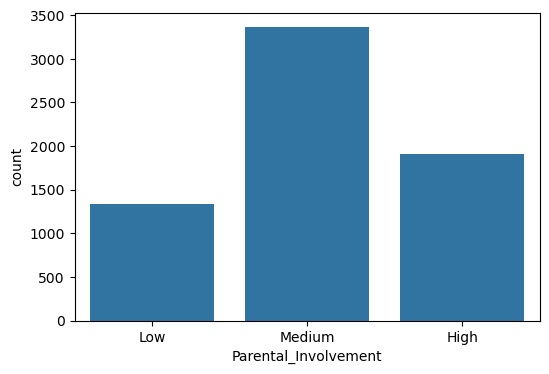

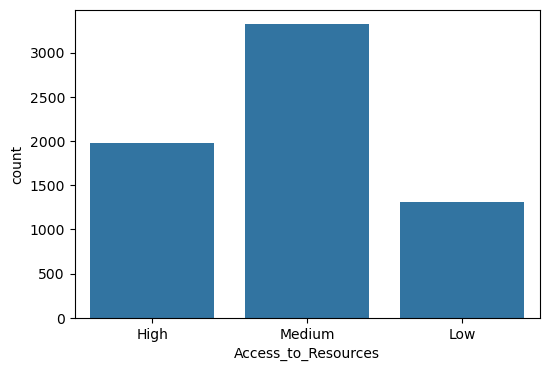

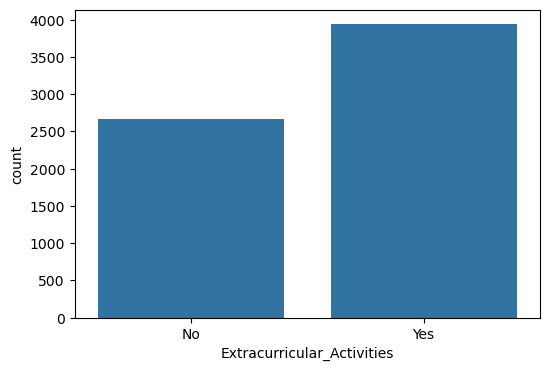

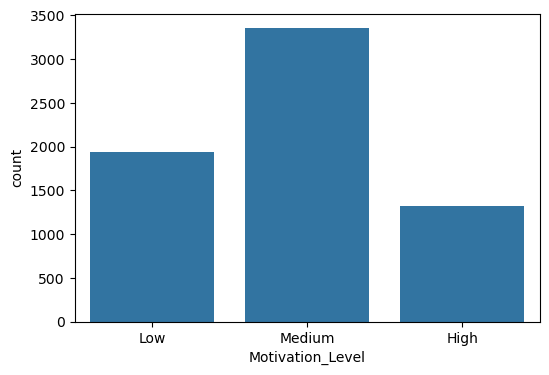

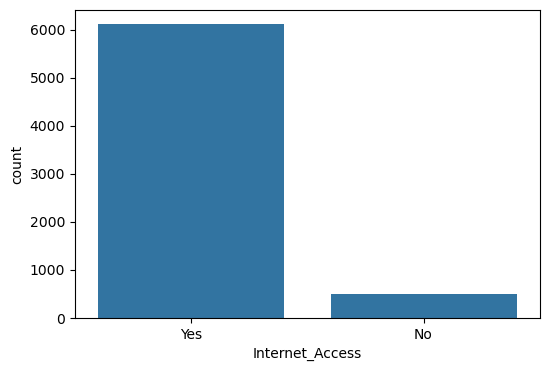

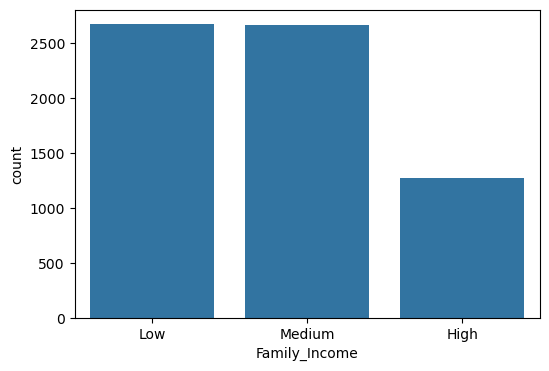

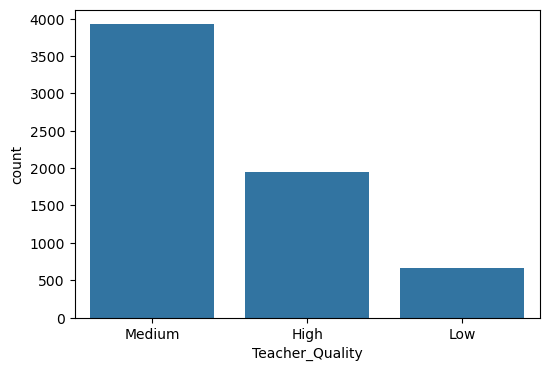

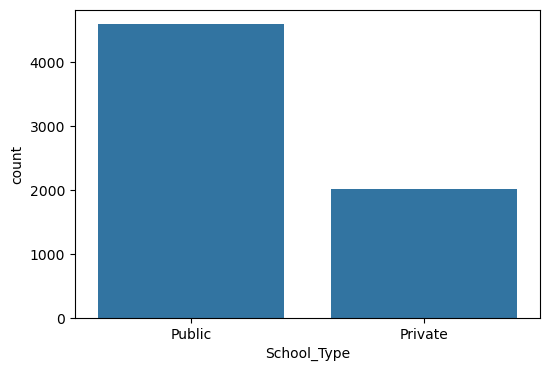

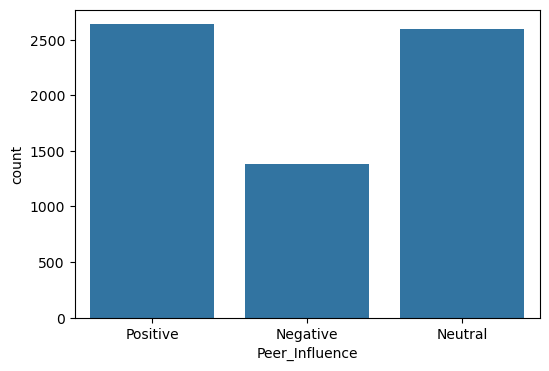

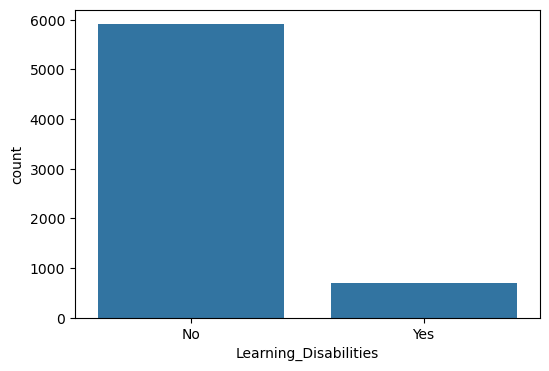

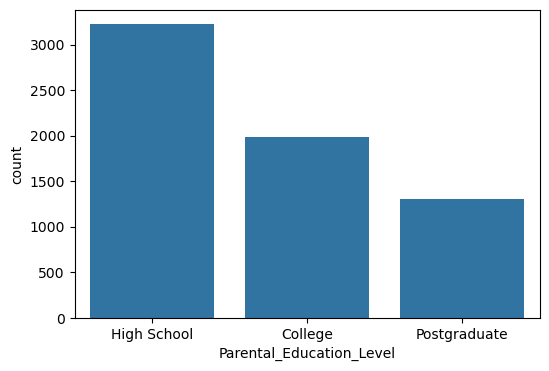

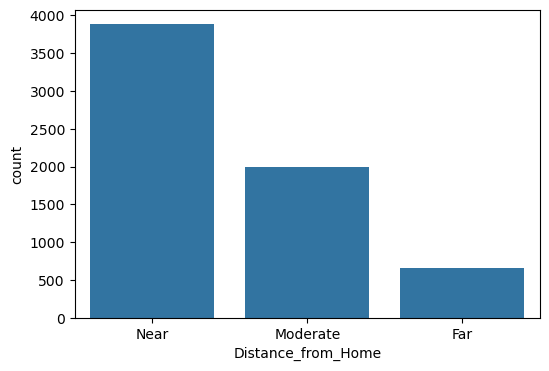

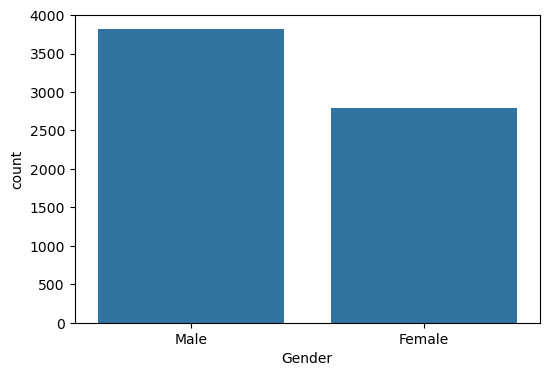

In [227]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])


<Axes: >

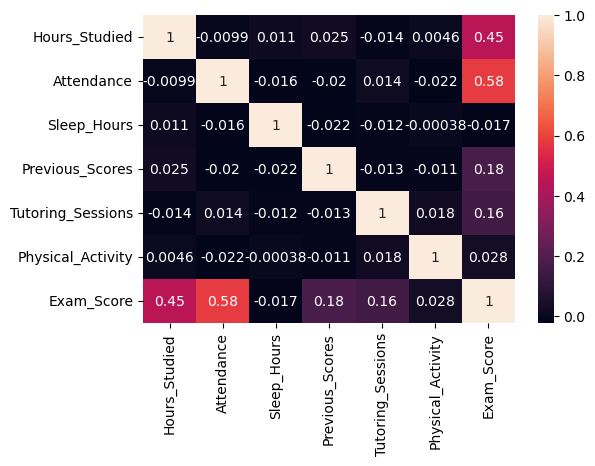

In [228]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Feature Engineering

In [229]:
df2 = df . copy()

In [230]:
df2.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [231]:
 cat_cols

['Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Motivation_Level',
 'Internet_Access',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender']

In [232]:
for cols in cat_cols:
    print(df2[cols].value_counts())
    print("\n\n\n")

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64




Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64




Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64




Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64




Internet_Access
Yes    6108
No      499
Name: count, dtype: int64




Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64




Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64




School_Type
Public     4598
Private    2009
Name: count, dtype: int64




Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64




Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64




Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64




Distance_from_Home
Nea

In [233]:
tf_cols =['Gender','Learning_Disabilities','School_Type','Internet_Access','Extracurricular_Activities']

### These are the columns where "label encoding" can be applied .

ordinal_features = [
    'Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 
    'Family_Income', 'Teacher_Quality', 'Peer_Influence', 
    'Parental_Education_Level', 'Distance_from_Home' ]
### The columns where one hot encoding can be done .

In [234]:
df2[ 'Learning_Disabilities'] = df2['Learning_Disabilities'].map({'No':0 , 'Yes' : 1}) ### Yes = 1 , No =0

df2['School_Type'] = df2['School_Type'].map({'Public' : 1 ,'Private' : 0})    ### Public = 1 ,Private =0

df2['Internet_Access'] = df2['Internet_Access'].map({'Yes' : 1 ,'No' : 0})   ### Yes = 1 ,No = 0 

df2['Gender']=df2['Gender'].map({'Male' : 0 , 'Female' : 1})     ### Male = 0 , Female = 1

df2['Extracurricular_Activities'] = df2['Extracurricular_Activities'].map({'Yes' : 1 ,'No' : 0})   ### Yes = 1 , No = 0

In [235]:
df2.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,0,7,73,Low,1,0,Low,Medium,1,Positive,3,0,High School,Near,0,67
1,19,64,Low,Medium,0,8,59,Low,1,2,Medium,Medium,1,Negative,4,0,College,Moderate,1,61
2,24,98,Medium,Medium,1,7,91,Medium,1,2,Medium,Medium,1,Neutral,4,0,Postgraduate,Near,0,74
3,29,89,Low,Medium,1,8,98,Medium,1,1,Medium,Medium,1,Negative,4,0,High School,Moderate,0,71
4,19,92,Medium,Medium,1,6,65,Medium,1,3,Medium,High,1,Neutral,4,0,College,Near,1,70


In [236]:
df2.rename(columns = {'Gender' : 'is_female',
                      'Learning_Disabilities' : 'is_disable_to_learn',
                      'School_Type' : 'is_public_school',
                      'Internet_Access' : 'is_net_access',
                      'Extracurricular_Activities' : 'ís_extracurr'} , inplace = True )

In [237]:
df2.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,ís_extracurr,Sleep_Hours,Previous_Scores,Motivation_Level,is_net_access,Tutoring_Sessions,Family_Income,Teacher_Quality,is_public_school,Peer_Influence,Physical_Activity,is_disable_to_learn,Parental_Education_Level,Distance_from_Home,is_female,Exam_Score
0,23,84,Low,High,0,7,73,Low,1,0,Low,Medium,1,Positive,3,0,High School,Near,0,67
1,19,64,Low,Medium,0,8,59,Low,1,2,Medium,Medium,1,Negative,4,0,College,Moderate,1,61
2,24,98,Medium,Medium,1,7,91,Medium,1,2,Medium,Medium,1,Neutral,4,0,Postgraduate,Near,0,74
3,29,89,Low,Medium,1,8,98,Medium,1,1,Medium,Medium,1,Negative,4,0,High School,Moderate,0,71
4,19,92,Medium,Medium,1,6,65,Medium,1,3,Medium,High,1,Neutral,4,0,College,Near,1,70


# In the ordinal fetures , there's need to apply the one-hot encoding method 

In [238]:
ordinal_features

['Parental_Involvement',
 'Access_to_Resources',
 'Motivation_Level',
 'Family_Income',
 'Teacher_Quality',
 'Peer_Influence',
 'Parental_Education_Level',
 'Distance_from_Home']

In [239]:
df2 = pd.get_dummies(df2 ,columns = ['Parental_Involvement',
 'Access_to_Resources',
 'Motivation_Level',
 'Family_Income',
 'Teacher_Quality',
 'Peer_Influence',
 'Parental_Education_Level',
 'Distance_from_Home'] , drop_first=True )

In [240]:
df2.head()  ### There are True and false , not numerical value .

,Hours_Studied,Attendance,ís_extracurr,Sleep_Hours,Previous_Scores,is_net_access,Tutoring_Sessions,is_public_school,Physical_Activity,is_disable_to_learn,is_female,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,Motivation_Level_Low,Motivation_Level_Medium,Family_Income_Low,Family_Income_Medium,Teacher_Quality_Low,Teacher_Quality_Medium,Peer_Influence_Neutral,Peer_Influence_Positive,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near
0,23,84,0,7,73,1,0,1,3,0,0,67,True,False,False,False,True,False,True,False,False,True,False,True,True,False,False,True
1,19,64,0,8,59,1,2,1,4,0,1,61,True,False,False,True,True,False,False,True,False,True,False,False,False,False,True,False
2,24,98,1,7,91,1,2,1,4,0,0,74,False,True,False,True,False,True,False,True,False,True,True,False,False,True,False,True
3,29,89,1,8,98,1,1,1,4,0,0,71,True,False,False,True,False,True,False,True,False,True,False,False,True,False,True,False
4,19,92,1,6,65,1,3,1,4,0,1,70,False,True,False,True,False,True,False,True,False,False,True,False,False,False,False,True


In [241]:
df2=df2.astype(int)

In [242]:
 df2.columns

Index(['Hours_Studied', 'Attendance', 'ís_extracurr', 'Sleep_Hours',
       'Previous_Scores', 'is_net_access', 'Tutoring_Sessions',
       'is_public_school', 'Physical_Activity', 'is_disable_to_learn',
       'is_female', 'Exam_Score', 'Parental_Involvement_Low',
       'Parental_Involvement_Medium', 'Access_to_Resources_Low',
       'Access_to_Resources_Medium', 'Motivation_Level_Low',
       'Motivation_Level_Medium', 'Family_Income_Low', 'Family_Income_Medium',
       'Teacher_Quality_Low', 'Teacher_Quality_Medium',
       'Peer_Influence_Neutral', 'Peer_Influence_Positive',
       'Parental_Education_Level_High School',
       'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate',
       'Distance_from_Home_Near'],
      dtype='object')

In [243]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### We can divivde a feature to different category , like below 

hours studied - low ( below 15 ), Avg(15-25) , GOOD(avobe 25 )

sleep hour - good(6-8) , less(below 6), over( above 8 )

atten - good (avobe 80) ,considerable(70-80) ,low(below 70) 

previous score - poor (below 65) , considerable(65-80) , good(avode 80)

tutoring session - none , normal(1-3) , excess (3-8) 



In [244]:
df2['hours_study_category'] = pd.cut(
    df2['Hours_Studied'],
    bins=[0,15,25,float('inf')],
    labels = ['poor','average','good']
)

In [245]:
df2['sleep_hour_category'] = pd.cut(
    df2['Sleep_Hours'],
    bins=[0,6,8,float('inf')],
    labels = ['poor','quality_sleep','over']
)

In [246]:
df2['attendance_category'] = pd.cut(
    df2['Attendance'],
    bins=[50,70,80,100],
    labels = ['poor','considerable','good']
)

In [247]:
df2['previous_scores_category'] = pd.cut(
    df2['Previous_Scores'],
    bins=[30,65,80,100],
    labels = ['poor','considerable','good']
)

In [248]:
df2['hours_study_category'] = pd.cut(
    df2['Hours_Studied'],
    bins=[0,1,3,8],
    labels = ['poor','average','good']
)

In [249]:
### Checking if there is any null values 

check_cols = ['hours_study_category', 'previous_scores_category', 'attendance_category', 'sleep_hour_category']
print(df2[check_cols].isnull().sum())

hours_study_category        6422
previous_scores_category       0
attendance_category            0
sleep_hour_category            0
dtype: int64


In [250]:
df2

### See again there is categorical fetures in the dataframe .
### So , we have to perform one-hot encoding to make the dataframe numerical .

,Hours_Studied,Attendance,ís_extracurr,Sleep_Hours,Previous_Scores,is_net_access,Tutoring_Sessions,is_public_school,Physical_Activity,is_disable_to_learn,is_female,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,Motivation_Level_Low,Motivation_Level_Medium,Family_Income_Low,Family_Income_Medium,Teacher_Quality_Low,Teacher_Quality_Medium,Peer_Influence_Neutral,Peer_Influence_Positive,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,hours_study_category,sleep_hour_category,attendance_category,previous_scores_category
0,23,84,0,7,73,1,0,1,3,0,0,67,1,0,0,0,1,0,1,0,0,1,0,1,1,0,0,1,NaN,quality_sleep,good,considerable
1,19,64,0,8,59,1,2,1,4,0,1,61,1,0,0,1,1,0,0,1,0,1,0,0,0,0,1,0,NaN,quality_sleep,poor,poor
2,24,98,1,7,91,1,2,1,4,0,0,74,0,1,0,1,0,1,0,1,0,1,1,0,0,1,0,1,NaN,quality_sleep,good,good
3,29,89,1,8,98,1,1,1,4,0,0,71,1,0,0,1,0,1,0,1,0,1,0,0,1,0,1,0,NaN,quality_sleep,good,good
4,19,92,1,6,65,1,3,1,4,0,1,70,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,1,NaN,poor,good,poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,0,7,76,1,1,1,2,0,1,68,0,0,0,1,0,1,0,0,0,1,0,1,1,0,0,1,NaN,quality_sleep,poor,considerable
6603,23,76,0,8,81,1,3,1,2,0,1,69,0,0,0,1,0,1,1,0,0,0,0,1,1,0,0,1,NaN,quality_sleep,considerable,good
6604,20,90,1,6,65,1,3,1,2,0,1,68,0,1,1,0,1,0,1,0,0,1,0,0,0,1,0,1,NaN,poor,good,poor
6605,10,86,1,6,91,1,2,0,3,0,1,68,0,0,0,0,0,0,1,0,0,1,0,1,1,0,0,0,NaN,poor,good,good


In [251]:
df2 = pd.get_dummies(df2,columns = 
['hours_study_category','previous_scores_category','attendance_category','sleep_hour_category']
                      ,drop_first =True )

In [252]:
df2=df2.astype(int)

In [253]:
df2.rename(columns={'Hours_Studied' : 'Hours_Studied_weekly'},inplace=True)

In [254]:
df2.head(20)

,Hours_Studied_weekly,Attendance,ís_extracurr,Sleep_Hours,Previous_Scores,is_net_access,Tutoring_Sessions,is_public_school,Physical_Activity,is_disable_to_learn,is_female,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,Motivation_Level_Low,Motivation_Level_Medium,Family_Income_Low,Family_Income_Medium,Teacher_Quality_Low,Teacher_Quality_Medium,Peer_Influence_Neutral,Peer_Influence_Positive,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,hours_study_category_average,hours_study_category_good,previous_scores_category_considerable,previous_scores_category_good,attendance_category_considerable,attendance_category_good,sleep_hour_category_quality_sleep,sleep_hour_category_over
0,23,84,0,7,73,1,0,1,3,0,0,67,1,0,0,0,1,0,1,0,0,1,0,1,1,0,0,1,0,0,1,0,0,1,1,0
1,19,64,0,8,59,1,2,1,4,0,1,61,1,0,0,1,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0
2,24,98,1,7,91,1,2,1,4,0,0,74,0,1,0,1,0,1,0,1,0,1,1,0,0,1,0,1,0,0,0,1,0,1,1,0
3,29,89,1,8,98,1,1,1,4,0,0,71,1,0,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1,0,1,1,0
4,19,92,1,6,65,1,3,1,4,0,1,70,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
5,19,88,1,8,89,1,3,1,3,0,0,71,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,1,0,1,1,0
6,29,84,1,7,68,1,1,0,2,0,0,67,0,1,1,0,1,0,1,0,0,1,1,0,1,0,1,0,0,0,1,0,0,1,1,0
7,25,78,1,6,50,1,1,1,2,0,0,66,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
8,17,94,0,6,80,1,0,0,1,0,0,69,0,1,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0
9,23,98,1,8,71,1,0,1,5,0,0,72,0,1,0,1,0,1,0,0,0,0,0,1,1,0,1,0,0,0,1,0,0,1,1,0


# See,the data is far better .And, now, We have to perform a feature scaling on numerical columns.
# We have to import a library to perform feature scaling and a little bit of use of oops.

In [255]:
num_cols = ['Hours_Studied_weekly',
 'Attendance',
 'Sleep_Hours',
 'Previous_Scores',
 'Tutoring_Sessions',
 'Physical_Activity']

In [256]:
num_cols

['Hours_Studied_weekly',
 'Attendance',
 'Sleep_Hours',
 'Previous_Scores',
 'Tutoring_Sessions',
 'Physical_Activity']

In [257]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
df2[num_cols]  =  scaler.fit_transform(df2[num_cols])

In [258]:
cat_cols

['Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Motivation_Level',
 'Internet_Access',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender']

In [259]:
import pandas as pd

correlations = df2.corr()['Exam_Score'].sort_values(ascending=True)

print("Correlation with Target Column:")
print(correlations)

Correlation with Target Column:
hours_study_category_good               -0.144204
Access_to_Resources_Low                 -0.132155
attendance_category_considerable        -0.121125
Parental_Involvement_Low                -0.113602
Parental_Education_Level_High School    -0.085818
is_disable_to_learn                     -0.085066
Family_Income_Low                       -0.082025
Motivation_Level_Low                    -0.080039
hours_study_category_average            -0.071837
Distance_from_Home_Moderate             -0.043019
Teacher_Quality_Low                     -0.041192
Teacher_Quality_Medium                  -0.039294
Parental_Involvement_Medium             -0.035978
Access_to_Resources_Medium              -0.026158
previous_scores_category_considerable   -0.017888
Sleep_Hours                             -0.017022
sleep_hour_category_over                -0.010196
is_public_school                        -0.008844
Peer_Influence_Neutral                  -0.007795
sleep_hour_categor

# The highly co-related or negetively related (above or less 0.5) features can be used
# z test, t test, chi square test , ANOVA test can be applied .

In [260]:
df2.columns 
## Total features exists in df2 dataframe 

Index(['Hours_Studied_weekly', 'Attendance', 'ís_extracurr', 'Sleep_Hours',
       'Previous_Scores', 'is_net_access', 'Tutoring_Sessions',
       'is_public_school', 'Physical_Activity', 'is_disable_to_learn',
       'is_female', 'Exam_Score', 'Parental_Involvement_Low',
       'Parental_Involvement_Medium', 'Access_to_Resources_Low',
       'Access_to_Resources_Medium', 'Motivation_Level_Low',
       'Motivation_Level_Medium', 'Family_Income_Low', 'Family_Income_Medium',
       'Teacher_Quality_Low', 'Teacher_Quality_Medium',
       'Peer_Influence_Neutral', 'Peer_Influence_Positive',
       'Parental_Education_Level_High School',
       'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate',
       'Distance_from_Home_Near', 'hours_study_category_average',
       'hours_study_category_good', 'previous_scores_category_considerable',
       'previous_scores_category_good', 'attendance_category_considerable',
       'attendance_category_good', 'sleep_hour_category_quali

In [261]:
cat_cols
## Defined before ; Running for recheck .

### 'Exam_Score' : This is the target column .

['Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Motivation_Level',
 'Internet_Access',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender']

In [262]:
df2.rename(columns={'ís_extracurr' : 'is_extracurr'},inplace=True)

### The silly mistake

In [263]:
import pandas as pd
import scipy.stats as stats

df3 = df2.copy()

target_col = 'Exam_Score'

cat_features = [col for col in df3.columns 
                if col != target_col and df3[col].nunique() <= 2]

anova_results = []

for col in cat_features:
    
    groups = [group[target_col].values 
              for name, group in df3.groupby(col)]
    
    if len(groups) == 2:
        f_stat, p_val = stats.f_oneway(*groups)
        
        anova_results.append({
            'Feature': col,
            'F-Statistic': round(f_stat, 4),
            'P-Value': round(p_val, 10),
            'Decision': 'Keep (Significant)' if p_val < 0.05 else 'Drop (Not Significant)'
        })

anova_df = pd.DataFrame(anova_results)

anova_df = anova_df.sort_values(by='P-Value')

print("ANOVA Test Results:")
print(anova_df)

ANOVA Test Results:
                                  Feature  F-Statistic       P-Value  \
3                     is_disable_to_learn      48.1434  0.000000e+00   
5                Parental_Involvement_Low      86.3554  0.000000e+00   
7                 Access_to_Resources_Low     117.4056  0.000000e+00   
11                      Family_Income_Low      44.7406  0.000000e+00   
20                Distance_from_Home_Near      47.9199  0.000000e+00   
18  Parental_Education_Level_Postgraduate      58.5842  0.000000e+00   
17   Parental_Education_Level_High School      49.0047  0.000000e+00   
16                Peer_Influence_Positive      43.8570  0.000000e+00   
24          previous_scores_category_good     145.8823  0.000000e+00   
25       attendance_category_considerable      98.3458  0.000000e+00   
26               attendance_category_good    2178.2716  0.000000e+00   
22              hours_study_category_good     140.2664  0.000000e+00   
9                    Motivation_Level_Low   

 # Target feature is Exam score .
 # And there are some variable significantly related to targer feature.
 # A new data frame is created only with the significant features .

 # From the dataframe , we can make prediction of exam scores by a machine learning model depending of some input of a student like(sleep hour, study hour, parental involving, number of tutor etc.)

In [264]:
significant_cols = [
    'is_disable_to_learn',
    'Parental_Involvement_Low',
    'Access_to_Resources_Low',
    'Family_Income_Low',
    'Distance_from_Home_Near',
    'Parental_Education_Level_Postgraduate',
    'Parental_Education_Level_High School',
    'Peer_Influence_Positive',
    'previous_scores_category_good',
    'attendance_category_considerable',
    'attendance_category_good',
    'hours_study_category_good',
    'Motivation_Level_Low',
    'hours_study_category_average',
    'is_extracurr',
    'is_net_access',
    'Distance_from_Home_Moderate',
    'Teacher_Quality_Low',
    'Teacher_Quality_Medium',
    'Parental_Involvement_Medium',
    'Access_to_Resources_Medium',
    'Motivation_Level_Medium'
]
significant_cols

['is_disable_to_learn',
 'Parental_Involvement_Low',
 'Access_to_Resources_Low',
 'Family_Income_Low',
 'Distance_from_Home_Near',
 'Parental_Education_Level_Postgraduate',
 'Parental_Education_Level_High School',
 'Peer_Influence_Positive',
 'previous_scores_category_good',
 'attendance_category_considerable',
 'attendance_category_good',
 'hours_study_category_good',
 'Motivation_Level_Low',
 'hours_study_category_average',
 'is_extracurr',
 'is_net_access',
 'Distance_from_Home_Moderate',
 'Teacher_Quality_Low',
 'Teacher_Quality_Medium',
 'Parental_Involvement_Medium',
 'Access_to_Resources_Medium',
 'Motivation_Level_Medium']

In [265]:
selected_df = df2[significant_cols + ['Exam_Score']]

# The pre-processed dataframe : 

In [266]:
selected_df


,is_disable_to_learn,Parental_Involvement_Low,Access_to_Resources_Low,Family_Income_Low,Distance_from_Home_Near,Parental_Education_Level_Postgraduate,Parental_Education_Level_High School,Peer_Influence_Positive,previous_scores_category_good,attendance_category_considerable,attendance_category_good,hours_study_category_good,Motivation_Level_Low,hours_study_category_average,is_extracurr,is_net_access,Distance_from_Home_Moderate,Teacher_Quality_Low,Teacher_Quality_Medium,Parental_Involvement_Medium,Access_to_Resources_Medium,Motivation_Level_Medium,Exam_Score
0,0,1,0,1,1,0,1,1,0,0,1,0,1,0,0,1,0,0,1,0,0,0,67
1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,1,0,1,0,61
2,0,0,0,0,1,1,0,0,1,0,1,0,0,0,1,1,0,0,1,1,1,1,74
3,0,1,0,0,0,0,1,0,1,0,1,0,0,0,1,1,1,0,1,0,1,1,71
4,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,1,1,1,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0,1,0,1,1,68
6603,0,0,0,1,1,0,1,1,1,1,0,0,0,0,0,1,0,0,0,0,1,1,69
6604,0,0,1,1,1,1,0,0,0,0,1,0,1,0,1,1,0,0,1,1,0,0,68
6605,0,0,0,1,0,0,1,1,1,0,1,0,0,0,1,1,0,0,1,0,0,0,68
